<a href="https://www.kaggle.com/code/lalit7881/india-exam-paper-leak-cases-and-incidents-eda-79?scriptVersionId=339886742" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/exam-paper-leak-cases-analysis/Paper_leaks_India.csv


## Loading dataset

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/srisyra02/exam-paper-leak-cases-analysis/Paper_leaks_India.csv",
    encoding="latin1"
)

df.head()

,Date of Exam/Incident,Exam Name,Conducting Body,Conducting Body Type,Area(s) of Incident,Leak Confirmation Status,Action taken,Note about action Taken,Note about incident,References,Appeared Students
0,26-08-2024,B.Ed. 4th Sem Exam : Creating an Inclusive School,Tamil Nadu Teachers Education University,State,Tamilnadu,accused,Alternative Question Paper Used,Alternative Question Paper Used,Paper leaked on social media before exam,TNTEU registrar relieved after reports of B.Ed...,NaN
1,04-08-2024,MBA 1st year Exam,Pondicherry University,Central,Pondicherry,confirmed,Exam Cancelled,Legal action against exam mafia,Paper leaked on social media before exam,Pondicherry University First-year MBBS Exam Pa...,NaN
2,06-07-2024,Foreign Medical Graduate Examination,National Board of Examinations in Medical Scie...,Central,Kerala,accused,Legal action taken and claim dismissed,"No Rexam and checking of evidence, claim dismi...",Paper leaked on social media,So far no evidence: Kerala Police on FMGE p...,NaN
3,30-06-2024,Agriculture Development Officers,Punjab Public Service Comission,State,Punjab,accused,NaN,No Rexam,Claim: Offical demanded bribe for leaking paper,"Now, ADO recruitment exam in Punjab under pape...",NaN
4,18-06-2024,UGC NET 2024,National Testing Agency,Central,All India,accused,No Rexam,Exam cancellation decision overruled by Suprem...,accusation of paper leak,Supreme Court upholds decision to cancel UGC N...,NaN


In [3]:
df.head()

,Date of Exam/Incident,Exam Name,Conducting Body,Conducting Body Type,Area(s) of Incident,Leak Confirmation Status,Action taken,Note about action Taken,Note about incident,References,Appeared Students
0,26-08-2024,B.Ed. 4th Sem Exam : Creating an Inclusive School,Tamil Nadu Teachers Education University,State,Tamilnadu,accused,Alternative Question Paper Used,Alternative Question Paper Used,Paper leaked on social media before exam,TNTEU registrar relieved after reports of B.Ed...,NaN
1,04-08-2024,MBA 1st year Exam,Pondicherry University,Central,Pondicherry,confirmed,Exam Cancelled,Legal action against exam mafia,Paper leaked on social media before exam,Pondicherry University First-year MBBS Exam Pa...,NaN
2,06-07-2024,Foreign Medical Graduate Examination,National Board of Examinations in Medical Scie...,Central,Kerala,accused,Legal action taken and claim dismissed,"No Rexam and checking of evidence, claim dismi...",Paper leaked on social media,So far no evidence: Kerala Police on FMGE p...,NaN
3,30-06-2024,Agriculture Development Officers,Punjab Public Service Comission,State,Punjab,accused,NaN,No Rexam,Claim: Offical demanded bribe for leaking paper,"Now, ADO recruitment exam in Punjab under pape...",NaN
4,18-06-2024,UGC NET 2024,National Testing Agency,Central,All India,accused,No Rexam,Exam cancellation decision overruled by Suprem...,accusation of paper leak,Supreme Court upholds decision to cancel UGC N...,NaN


In [4]:
df.tail()

,Date of Exam/Incident,Exam Name,Conducting Body,Conducting Body Type,Area(s) of Incident,Leak Confirmation Status,Action taken,Note about action Taken,Note about incident,References,Appeared Students
61,01-05-2016,NEET Phase 1 2016,CBSE,Central,Uttar Pradesh,confirmed,Legal action taken,No Rexam,Cheating reported,NEET Phase 1 2016: Paper leaked in Varanasi - ...,NaN
62,25-05-2015,UP CPMT 2015,"King George's Medical University , Lucknow",State,Uttar Pradesh,confirmed,Legal action taken,No Rexam,Paper leaked on social media,Bid to leak UP CPMT answers: 3 MBBS students a...,NaN
63,03-05-2015,AIPMT 2015,CBSE,Central,All India,confirmed,Exam Cancelled,Legal action against exam mafia,Paper leaked on social media,"AIPMT cancelled, CBSE told to reconduct exam -...",NaN
64,30-03-2015,Provincial civil services preliminary examination,Uttar Pradesh Public Service Comission,State,Uttar Pradesh,confirmed,Exam Cancelled,Legal action against exam mafia,Paper leaked on social media before exam,Uttar Pradesh civil services exam cancelled af...,NaN
65,23-06-2014,UP CPMT 2014,"King George's Medical University , Ghaziabadd",State,Uttar Pradesh,confirmed,Exam Cancelled,Legal action against exam mafia,Paper leaked on social media,"CPMT 2014 paper leak: Aspirants dejected, dema...",NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date of Exam/Incident     66 non-null     object 
 1   Exam Name                 66 non-null     object 
 2   Conducting Body           66 non-null     object 
 3   Conducting Body Type      66 non-null     object 
 4   Area(s) of Incident       66 non-null     object 
 5   Leak Confirmation Status  66 non-null     object 
 6   Action taken              64 non-null     object 
 7   Note about action Taken   66 non-null     object 
 8   Note about incident       66 non-null     object 
 9   References                66 non-null     object 
 10  Appeared Students         1 non-null      float64
dtypes: float64(1), object(10)
memory usage: 5.8+ KB


In [6]:
df.describe()

,Appeared Students
count,1.0
mean,183.0
std,NaN
min,183.0
25%,183.0
50%,183.0
75%,183.0
max,183.0


In [7]:
df.isnull().sum()

Date of Exam/Incident        0
Exam Name                    0
Conducting Body              0
Conducting Body Type         0
Area(s) of Incident          0
Leak Confirmation Status     0
Action taken                 2
Note about action Taken      0
Note about incident          0
References                   0
Appeared Students           65
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date of Exam/Incident        object
Exam Name                    object
Conducting Body              object
Conducting Body Type         object
Area(s) of Incident          object
Leak Confirmation Status     object
Action taken                 object
Note about action Taken      object
Note about incident          object
References                   object
Appeared Students           float64
dtype: object

In [10]:
df.shape

(66, 11)

In [11]:
df.nunique()

Date of Exam/Incident       66
Exam Name                   63
Conducting Body             53
Conducting Body Type         3
Area(s) of Incident         24
Leak Confirmation Status     2
Action taken                12
Note about action Taken     22
Note about incident         29
References                  66
Appeared Students            1
dtype: int64

In [12]:
df.columns

Index(['Date of Exam/Incident', 'Exam Name', 'Conducting Body',
       'Conducting Body Type', 'Area(s) of Incident',
       'Leak Confirmation Status', 'Action taken', 'Note about action Taken',
       'Note about incident', 'References ', 'Appeared Students'],
      dtype='object')

## EDA

  Date of Exam/Incident                                          Exam Name  \
0            26-08-2024  B.Ed. 4th Sem Exam : Creating an Inclusive School   
1            04-08-2024                                  MBA 1st year Exam   
2            06-07-2024               Foreign Medical Graduate Examination   
3            30-06-2024                  Agriculture Development Officers    
4            18-06-2024                                       UGC NET 2024   

                                     Conducting Body Conducting Body Type  \
0           Tamil Nadu Teachers Education University                State   
1                             Pondicherry University              Central   
2  National Board of Examinations in Medical Scie...              Central   
3                    Punjab Public Service Comission                State   
4                            National Testing Agency              Central   

  Area(s) of Incident Leak Confirmation Status  \
0           Tamiln

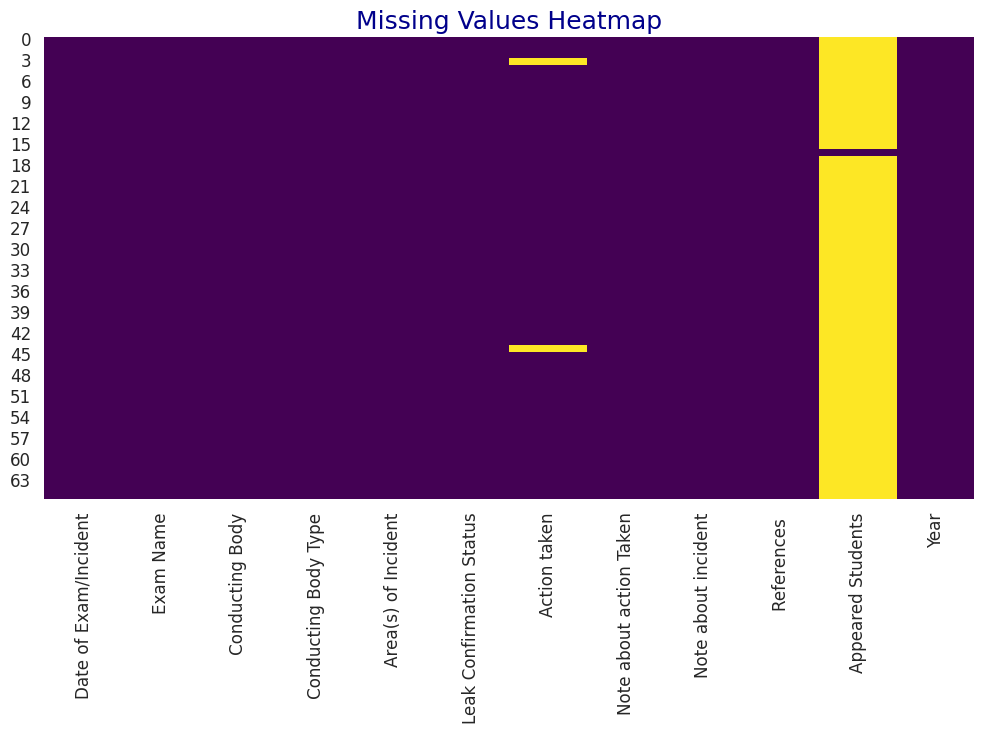

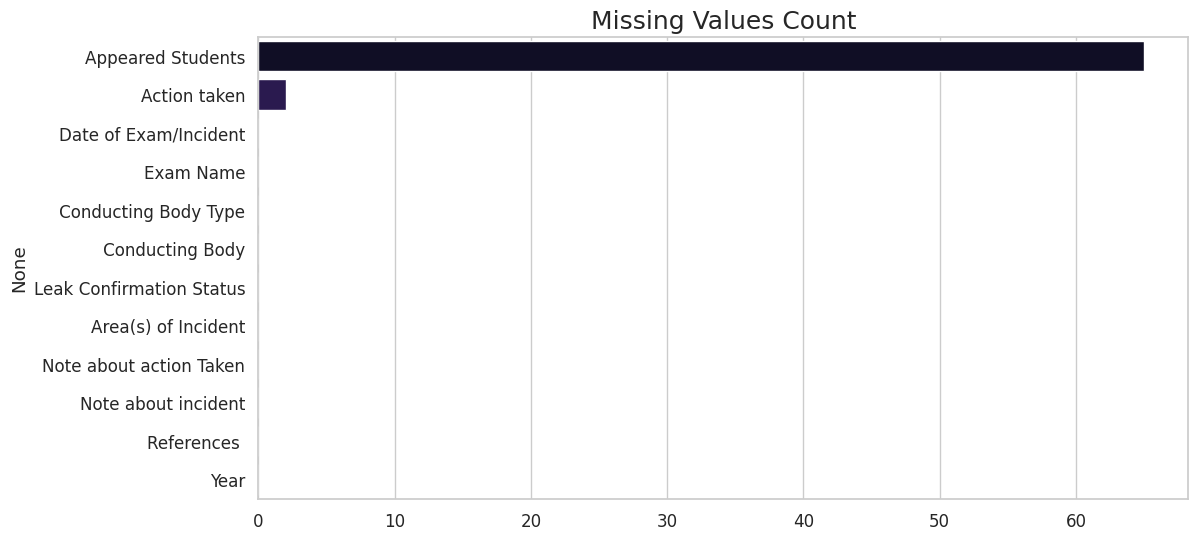

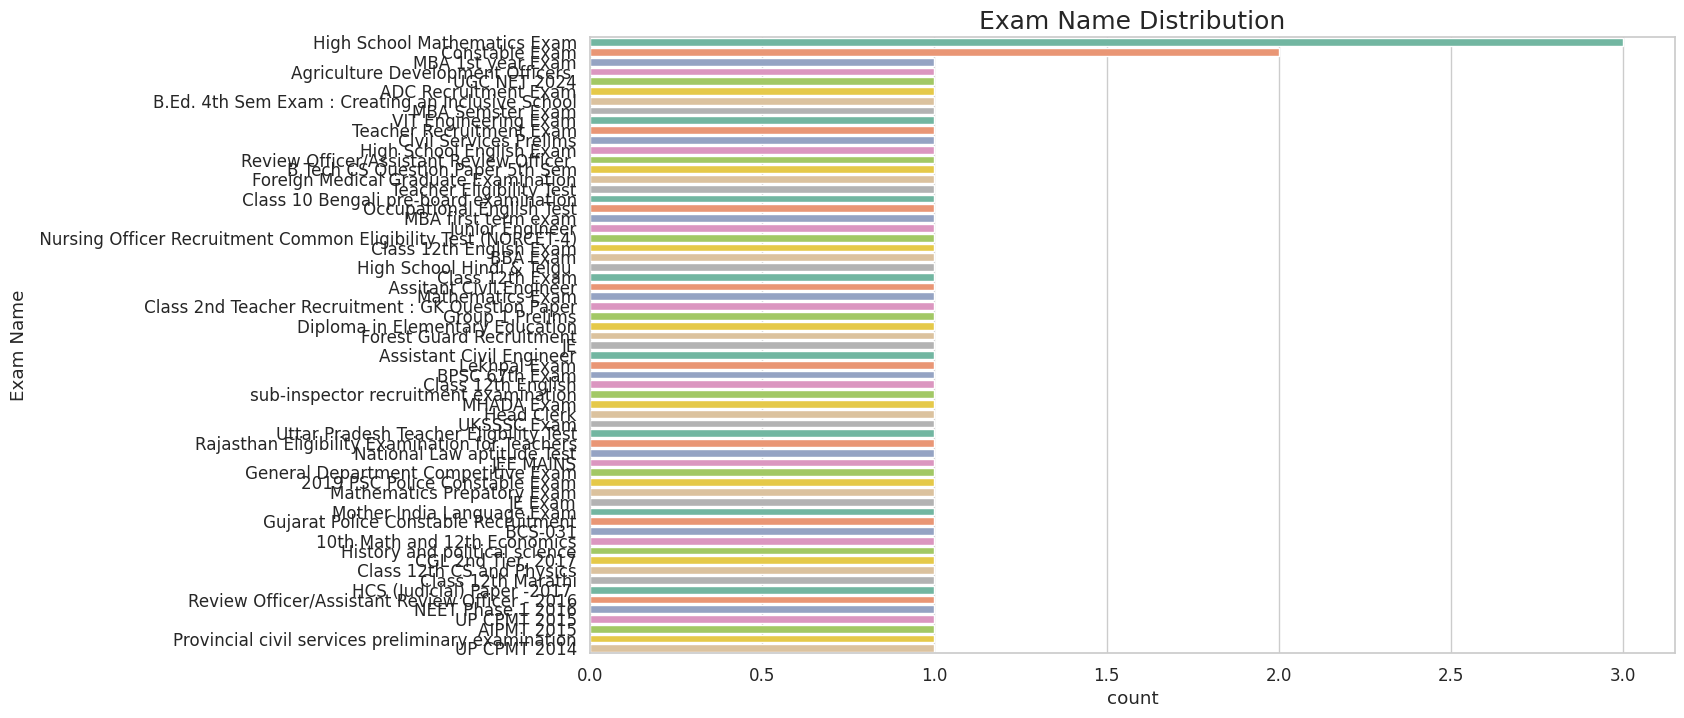

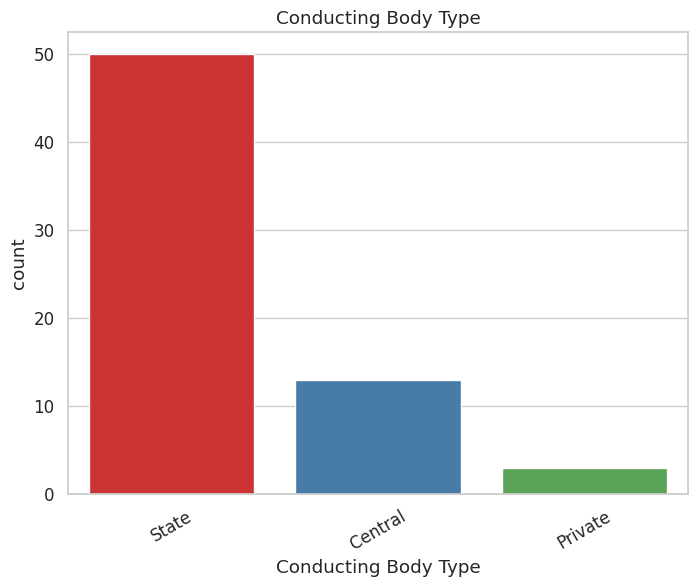

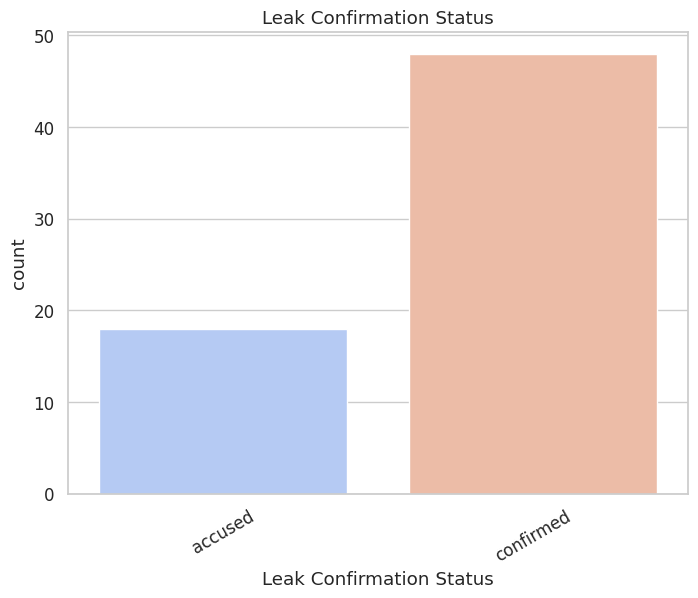

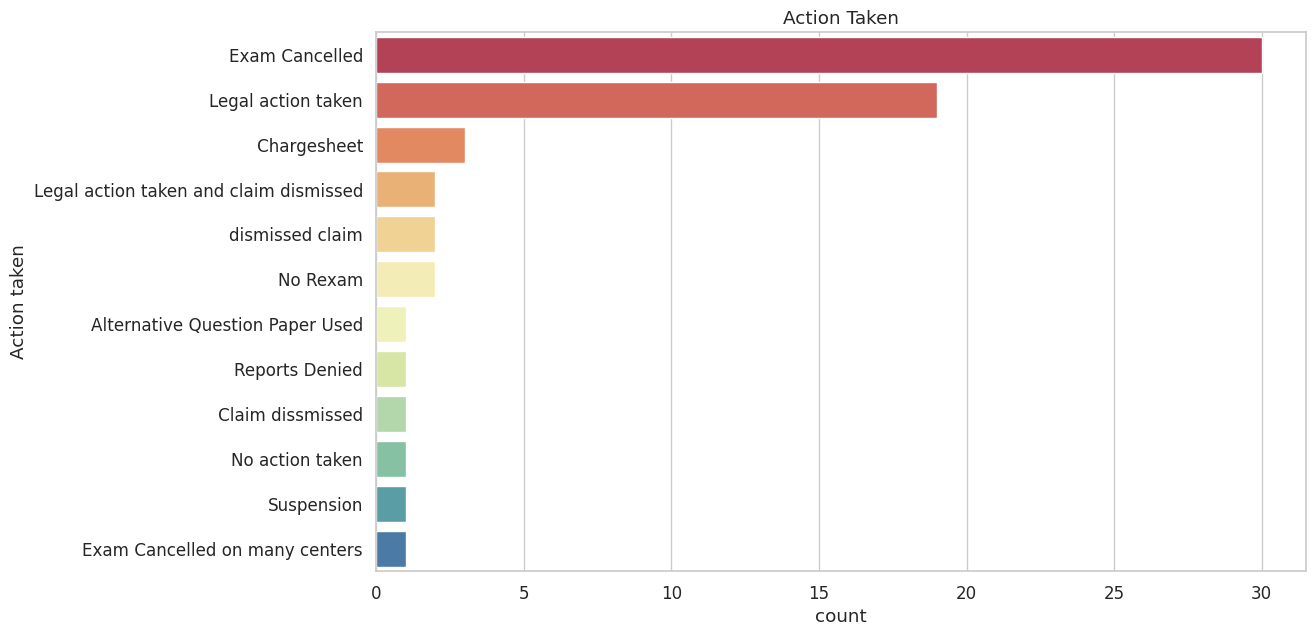

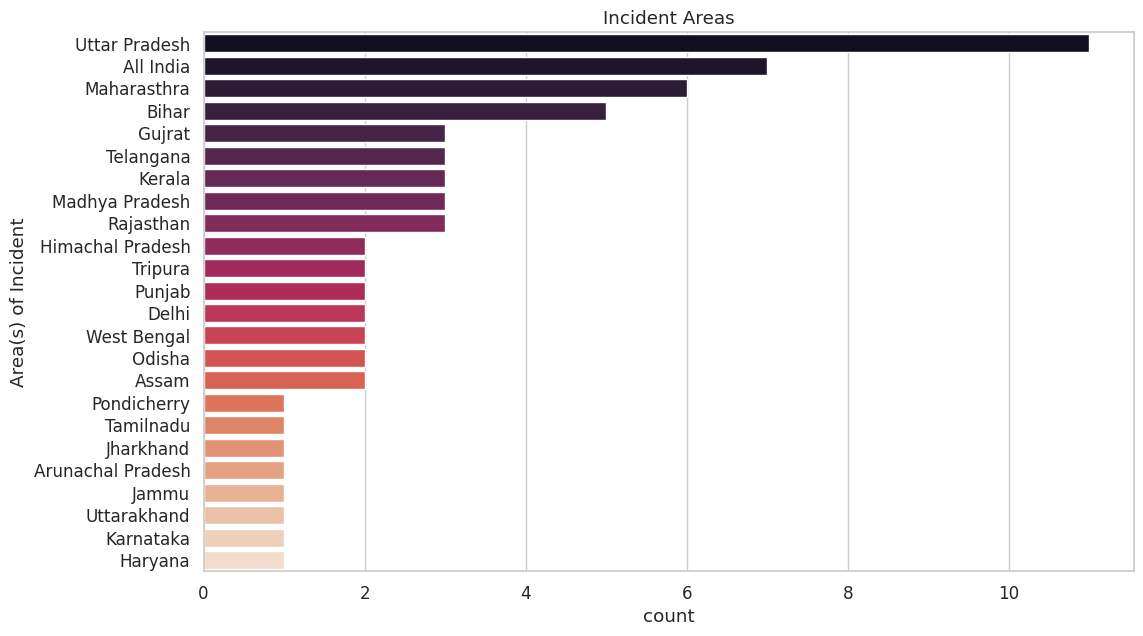

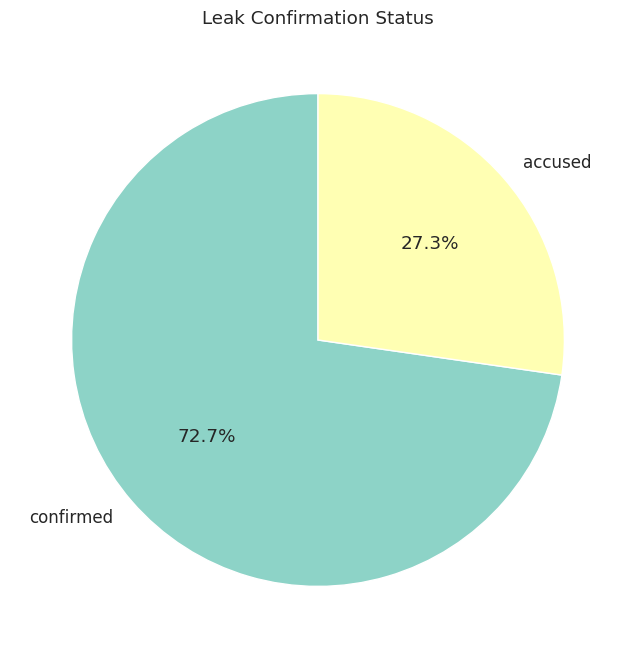

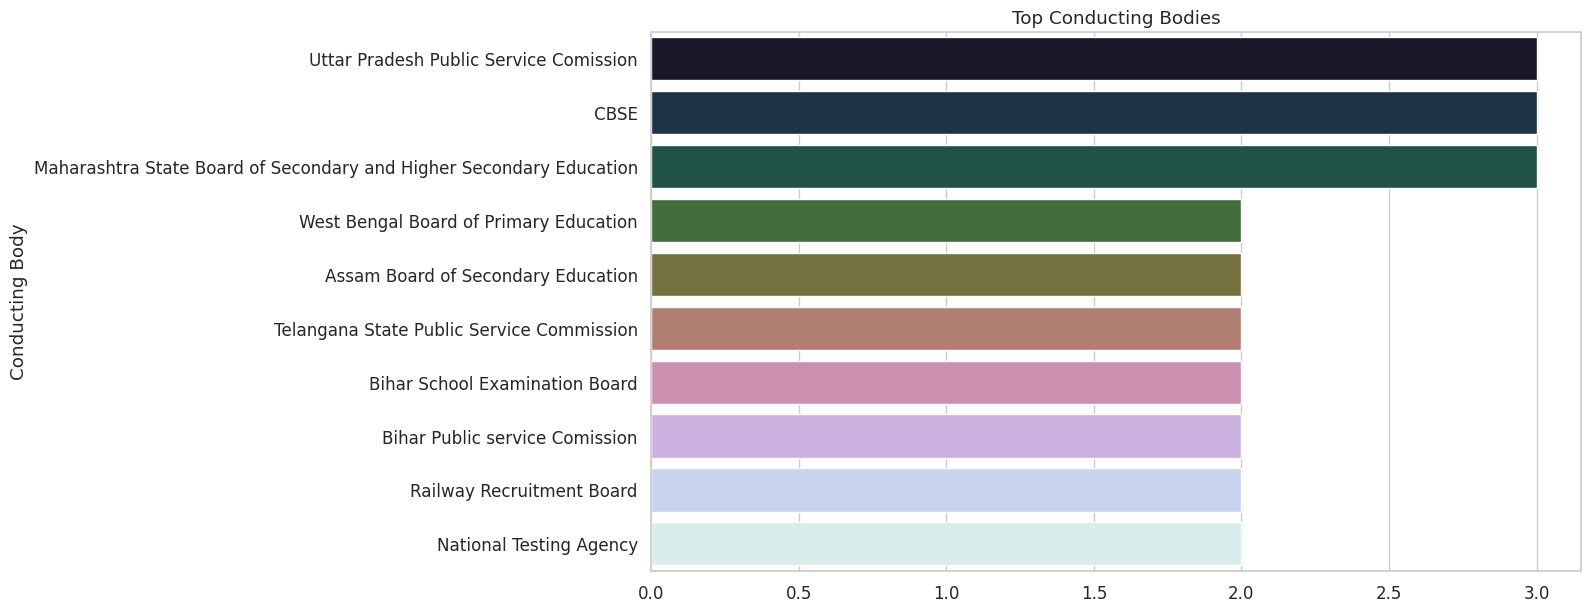

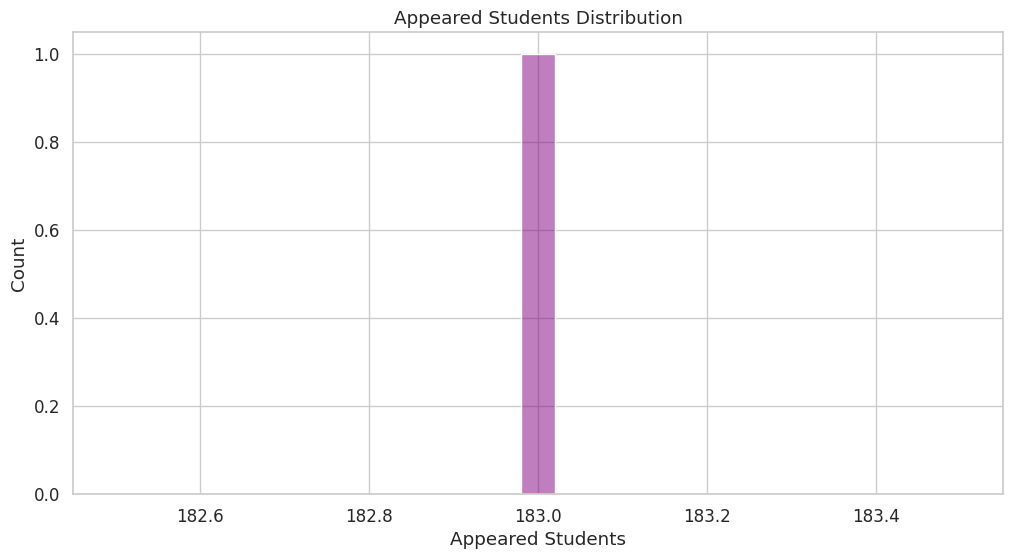

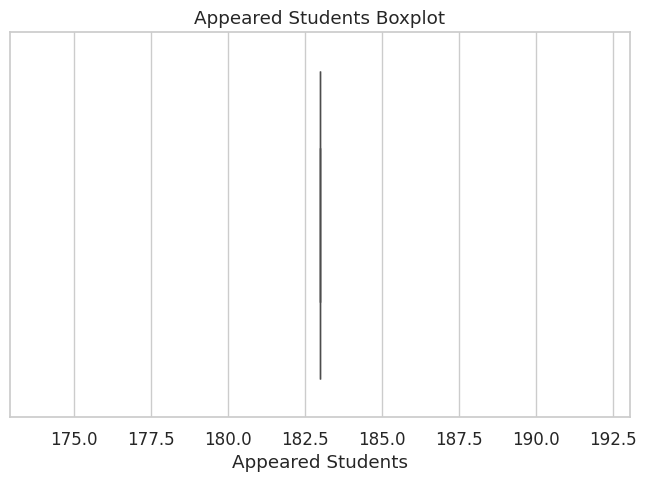

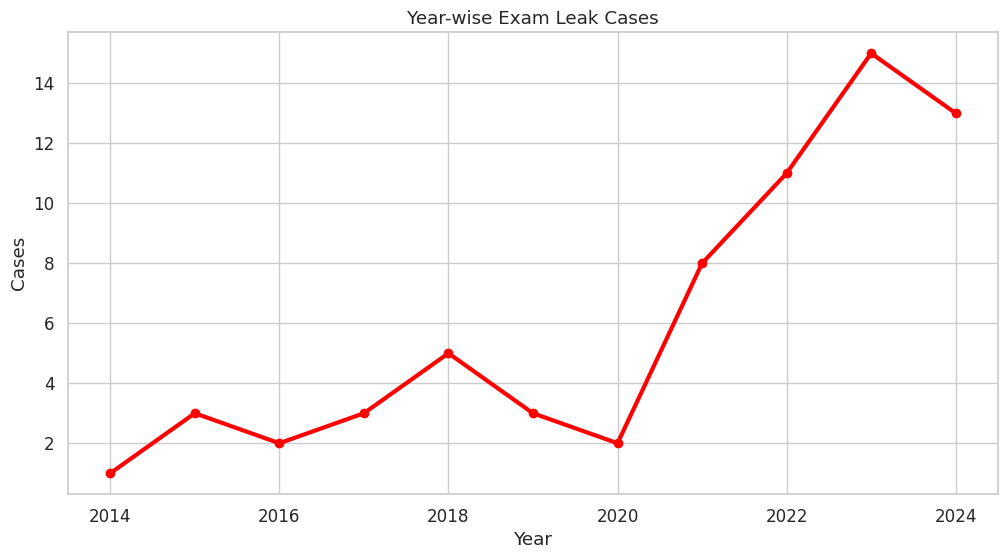

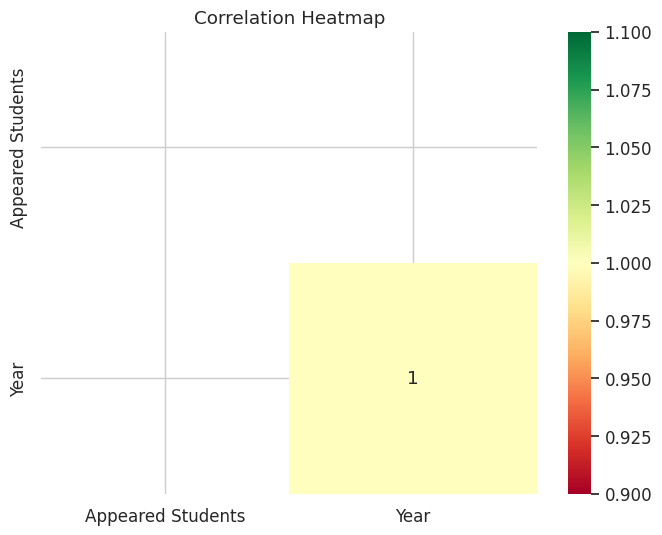

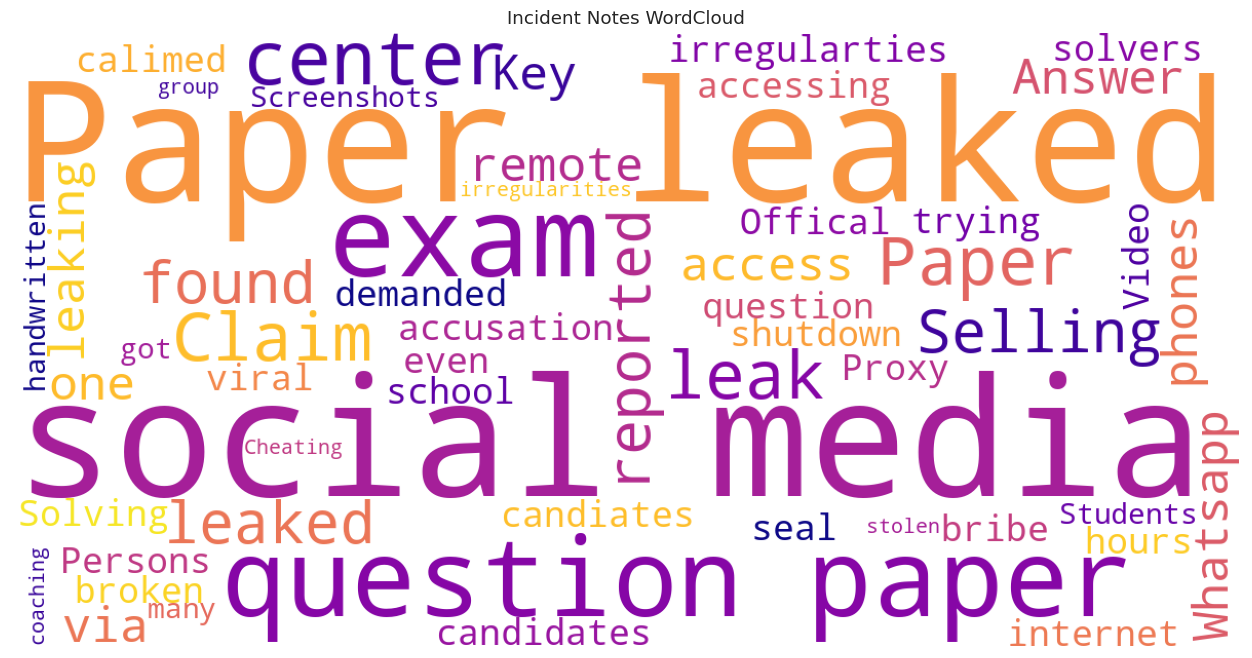

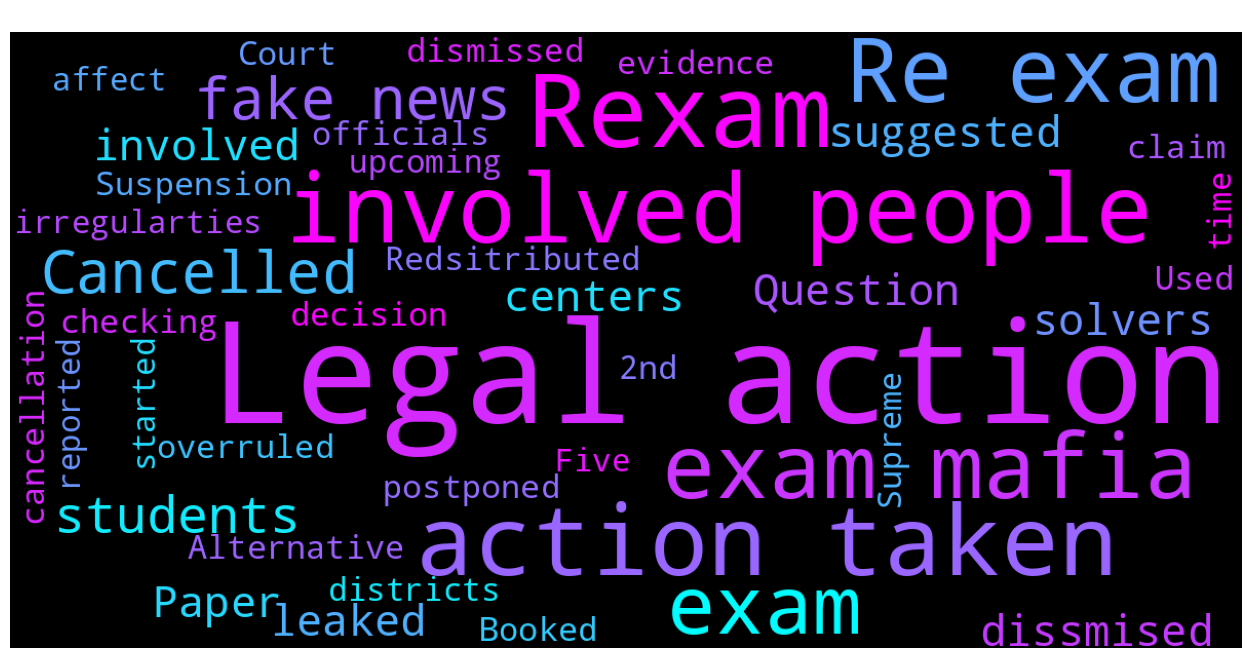

Dataset Shape : (66, 12)
Duplicate Rows : 0
Missing Values :
Date of Exam/Incident        0
Exam Name                    0
Conducting Body              0
Conducting Body Type         0
Area(s) of Incident          0
Leak Confirmation Status     0
Action taken                 2
Note about action Taken      0
Note about incident          0
References                   0
Appeared Students           65
Year                         0
dtype: int64


In [13]:
import plotly.express as px

from wordcloud import WordCloud

plt.style.use("ggplot")
sns.set(style="whitegrid", font_scale=1.1)

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv(
    "/kaggle/input/datasets/srisyra02/exam-paper-leak-cases-analysis/Paper_leaks_India.csv",
    encoding="latin1"
)

print(df.head())
print(df.info())
print(df.describe(include="all"))

# ==========================================================
# DATE CONVERSION
# ==========================================================

df["Date of Exam/Incident"] = pd.to_datetime(
    df["Date of Exam/Incident"],
    errors="coerce"
)

df["Year"] = df["Date of Exam/Incident"].dt.year

# ==========================================================
# MISSING VALUES
# ==========================================================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=18,
          color="darkblue")

plt.show()

# ==========================================================
# MISSING VALUE COUNT
# ==========================================================

plt.figure(figsize=(12,6))

missing=df.isnull().sum().sort_values(ascending=False)

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="magma"
)

plt.title("Missing Values Count",
          fontsize=18)

plt.show()

# ==========================================================
# EXAM NAME
# ==========================================================

plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y="Exam Name",
    order=df["Exam Name"].value_counts().index,
    palette="Set2"
)

plt.title("Exam Name Distribution",
          fontsize=18)

plt.show()

# ==========================================================
# CONDUCTING BODY TYPE
# ==========================================================

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="Conducting Body Type",
    palette="Set1"
)

plt.xticks(rotation=30)

plt.title("Conducting Body Type")

plt.show()

# ==========================================================
# LEAK CONFIRMATION STATUS
# ==========================================================

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="Leak Confirmation Status",
    palette="coolwarm"
)

plt.xticks(rotation=30)

plt.title("Leak Confirmation Status")

plt.show()

# ==========================================================
# ACTION TAKEN
# ==========================================================

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Action taken",
    order=df["Action taken"].value_counts().index,
    palette="Spectral"
)

plt.title("Action Taken")

plt.show()

# ==========================================================
# AREA OF INCIDENT
# ==========================================================

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Area(s) of Incident",
    order=df["Area(s) of Incident"].value_counts().index,
    palette="rocket"
)

plt.title("Incident Areas")

plt.show()

# ==========================================================
# PIE CHART
# ==========================================================

status=df["Leak Confirmation Status"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    colors=plt.cm.Set3.colors,
    startangle=90
)

plt.title("Leak Confirmation Status")

plt.show()

# ==========================================================
# TOP CONDUCTING BODY
# ==========================================================

plt.figure(figsize=(12,7))

top=df["Conducting Body"].value_counts().head(10)

sns.barplot(
    x=top.values,
    y=top.index,
    palette="cubehelix"
)

plt.title("Top Conducting Bodies")

plt.show()

# ==========================================================
# APPEARED STUDENTS
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df["Appeared Students"],
    bins=25,
    color="purple",
    kde=True
)

plt.title("Appeared Students Distribution")

plt.show()

# ==========================================================
# BOXPLOT
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Appeared Students"],
    color="orange"
)

plt.title("Appeared Students Boxplot")

plt.show()

# ==========================================================
# YEARWISE INCIDENTS
# ==========================================================

year=df["Year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    year.index,
    year.values,
    marker="o",
    linewidth=3,
    color="red"
)

plt.grid(True)

plt.title("Year-wise Exam Leak Cases")

plt.xlabel("Year")
plt.ylabel("Cases")

plt.show()

# ==========================================================
# CORRELATION
# ==========================================================

num=df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    num.corr(),
    annot=True,
    cmap="RdYlGn"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# WORD CLOUD
# ==========================================================

text=" ".join(df["Note about incident"].dropna().astype(str))

wordcloud=WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="plasma"
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Incident Notes WordCloud")

plt.show()

# ==========================================================
# WORD CLOUD ACTION NOTES
# ==========================================================

text=" ".join(df["Note about action Taken"].dropna().astype(str))

wordcloud=WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="cool"
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Action Notes WordCloud",
          color="white")

plt.show()

# ==========================================================
# PLOTLY EXAM DISTRIBUTION
# ==========================================================

fig=px.bar(
    df["Exam Name"].value_counts().reset_index(),
    x="count",
    y="Exam Name",
    orientation="h",
    color="count",
    color_continuous_scale="Turbo",
    title="Exam Distribution"
)

fig.show()

# ==========================================================
# PLOTLY LEAK STATUS
# ==========================================================

fig=px.pie(
    df,
    names="Leak Confirmation Status",
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Leak Confirmation Status"
)

fig.show()

# ==========================================================
# PLOTLY YEAR TREND
# ==========================================================

year=df.groupby("Year").size().reset_index(name="Cases")

fig=px.line(
    year,
    x="Year",
    y="Cases",
    markers=True,
    color_discrete_sequence=["red"],
    title="Year-wise Leak Cases"
)

fig.show()

# ==========================================================
# PLOTLY STUDENTS
# ==========================================================

fig=px.histogram(
    df,
    x="Appeared Students",
    nbins=30,
    color_discrete_sequence=["purple"],
    title="Appeared Students Distribution"
)

fig.show()

# ==========================================================
# SUMMARY
# ==========================================================

print("="*60)
print("Dataset Shape :", df.shape)
print("Duplicate Rows :", df.duplicated().sum())
print("Missing Values :")
print(df.isnull().sum())
print("="*60)

## Feature engineering

In [14]:
df['Exam_Date_Ordinal'] = df['Date of Exam/Incident'].apply(lambda x: x.toordinal())
print(df.head())

  Date of Exam/Incident                                          Exam Name  \
0            2024-08-26  B.Ed. 4th Sem Exam : Creating an Inclusive School   
1            2024-08-04                                  MBA 1st year Exam   
2            2024-07-06               Foreign Medical Graduate Examination   
3            2024-06-30                  Agriculture Development Officers    
4            2024-06-18                                       UGC NET 2024   

                                     Conducting Body Conducting Body Type  \
0           Tamil Nadu Teachers Education University                State   
1                             Pondicherry University              Central   
2  National Board of Examinations in Medical Scie...              Central   
3                    Punjab Public Service Comission                State   
4                            National Testing Agency              Central   

  Area(s) of Incident Leak Confirmation Status  \
0           Tamiln

In [15]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

Missing values in features before imputation:
Appeared Students    65
Exam_Date_Ordinal     0
dtype: int64
Prediction Accuracy: 0.79


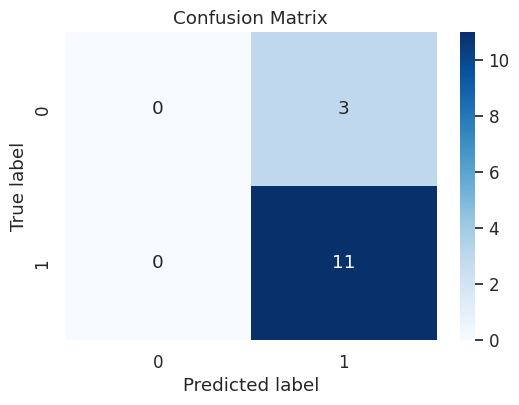

In [16]:
model_df = df.copy()

# Check for missing values in the modeling features
print('Missing values in features before imputation:')
print(model_df[['Appeared Students', 'Exam_Date_Ordinal']].isnull().sum())

# Impute missing values in 'Appeared Students' with the median
imputer = SimpleImputer(strategy='median')
model_df[['Appeared Students']] = imputer.fit_transform(model_df[['Appeared Students']])

# Prepare the features and target variable
features = ['Appeared Students', 'Exam_Date_Ordinal']
target = 'Leak Confirmation Status'

# Encode the target labels
le = LabelEncoder()
model_df[target] = le.fit_transform(model_df[target].astype(str))

# Define X and y
X = model_df[features]
y = model_df[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train a Logistic Regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Prediction Accuracy: {acc:.2f}')

# Compute confusion matrix and visualize it using seaborn heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

## Thank you..pls upvote!!!!!!!!